In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import os
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# 忽略所有警告
warnings.filterwarnings("ignore")

# 设置字体和负号显示
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
path = "data.xlsx"
df = pd.read_excel(path)

# 划分特征和目标变量
X = df.drop(['CRL'], axis=1)
y = df['CRL']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 定义 XGBoost 回归模型
model_xgb = XGBRegressor(random_state=8)

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 使用 K 折交叉验证
kfold = KFold(n_splits=5, shuffle=True, random_state=8)

# 使用网格搜索寻找最佳参数
grid_search = GridSearchCV(
    estimator=model_xgb, param_grid=param_grid, scoring='neg_mean_squared_error', cv=kfold, verbose=1, n_jobs=-1
)

# 拟合模型
grid_search.fit(X_train, y_train)

# 使用最优参数训练模型
xgboost = grid_search.best_estimator_

# 将标准输出重定向到 os.devnull
sys.stdout = open(os.devnull, 'w')

# SHAP 解释模型
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)

# 将"Lδ"的特征放在第一位
sorted_feature_names = X_test.columns.tolist()
sorted_feature_names.remove("Lδ")
sorted_feature_names.insert(0, "Lδ")

# 绘制 SHAP 值总结图
plt.figure(figsize=(10, 8), dpi=600)  # 设置图像大小和清晰度

# 使用 SHAP summary_plot，并调整样式
shap.summary_plot(
    shap_values, X_test[sorted_feature_names], 
    feature_names=sorted_feature_names, plot_type="dot", 
    max_display=10, show=False, cmap="coolwarm"
)

# 美化处理：修改散点的边框，增加字体加粗
plt.gca().tick_params(axis='both', labelsize=14, width=2)  # 设置坐标轴字体大小和线宽
plt.title('SHAP Feature Importance', fontsize=18, fontweight='bold')  # 设置标题字体加粗
plt.xlabel('SHAP Value', fontsize=16, fontweight='bold')  # 设置x轴标签字体加粗
plt.ylabel('Features', fontsize=16, fontweight='bold')  # 设置y轴标签字体加粗

plt.show()

# 评估模型性能
y_pred = xgboost.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import os
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# 忽略所有警告
warnings.filterwarnings("ignore")

# 设置字体和负号显示
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
path = "data.xlsx"
df = pd.read_excel(path)

# 划分特征和目标变量
X = df.drop(['CRL'], axis=1)
y = df['CRL']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 定义 XGBoost 回归模型
model_xgb = XGBRegressor(random_state=8)

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 使用 K 折交叉验证
kfold = KFold(n_splits=5, shuffle=True, random_state=8)

# 使用网格搜索寻找最佳参数
grid_search = GridSearchCV(
    estimator=model_xgb, param_grid=param_grid, scoring='neg_mean_squared_error', cv=kfold, verbose=1, n_jobs=-1
)

# 拟合模型
grid_search.fit(X_train, y_train)

# 使用最优参数训练模型
xgboost = grid_search.best_estimator_

# 将标准输出重定向到 os.devnull
sys.stdout = open(os.devnull, 'w')

# SHAP 解释模型
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)

# 绘制 SHAP 值总结图
plt.figure(figsize=(10, 8), dpi=600)  # 设置图像大小和清晰度
shap.summary_plot(
    shap_values, X_test, feature_names=X_test.columns, plot_type="dot", max_display=10, show=False, cmap="coolwarm"
)

plt.show()

# 评估模型性能
y_pred = xgboost.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# 假设 shap_values 和 X_test 已经定义
# 获取特征名
features = X_test.columns.tolist()

# 计算每个特征的重要性（基于 SHAP 值）
shap_importances = np.abs(shap_values).mean(axis=0)

# 获取前 10 个最重要的特征
top_features_idx = np.argsort(shap_importances)[-10:][::-1]
top_features = [features[i] for i in top_features_idx]
top_importances = shap_importances[top_features_idx]

# 归一化重要性值
normalized_importances = top_importances / np.sum(top_importances)

# 创建极坐标图
theta = np.linspace(0, 2 * np.pi, len(top_features), endpoint=False)  # 每个特征对应的角度
radii = normalized_importances  # 对应特征的重要性值
width = np.pi / 10 * np.ones_like(theta)  # 每个特征的宽度

# 创建极坐标图
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(10, 8), dpi=600)
bars = ax.bar(theta, radii, width=width, color=plt.cm.coolwarm(radii), edgecolor="black")

# 添加标签
ax.set_xticks(theta)
ax.set_xticklabels(top_features, fontsize=25, fontweight='bold')

# 设置图的范围
ax.set_ylim(0, 0.3)


# 显示图形
plt.tight_layout()

plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import os
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# 忽略所有警告
warnings.filterwarnings("ignore")

# 设置字体和负号显示
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
path = "data.xlsx"
df = pd.read_excel(path)

# 划分特征和目标变量
X = df.drop(['CRL'], axis=1)
y = df['CRL']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 定义 XGBoost 回归模型
model_xgb = XGBRegressor(random_state=8)

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 使用 K 折交叉验证
kfold = KFold(n_splits=5, shuffle=True, random_state=8)

# 使用网格搜索寻找最佳参数
grid_search = GridSearchCV(
    estimator=model_xgb, param_grid=param_grid, scoring='neg_mean_squared_error', cv=kfold, verbose=1, n_jobs=-1
)

# 拟合模型
grid_search.fit(X_train, y_train)

# 使用最优参数训练模型
xgboost = grid_search.best_estimator_

# 将标准输出重定向到 os.devnull
sys.stdout = open(os.devnull, 'w')

# SHAP 解释模型
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)

# 将"Lδ"的特征放在第一位
sorted_feature_names = X_test.columns.tolist()
sorted_feature_names.remove("Lδ")
sorted_feature_names.insert(0, "Lδ")

# 绘制 SHAP 值总结图
plt.figure(figsize=(10, 8), dpi=600)  # 设置图像大小和清晰度

# 使用 SHAP summary_plot，并调整样式
shap.summary_plot(
    shap_values, X_test[sorted_feature_names], 
    feature_names=sorted_feature_names, plot_type="dot", 
    max_display=10, show=False, cmap="coolwarm"
)

# 获取当前的散点对象
ax = plt.gca()
for scatter in ax.collections:
    scatter.set_edgecolor('black')  # 设置外边框为黑色
    scatter.set_linewidth(1.5)  # 设置外边框的粗细

# 美化处理：修改散点的边框，增加字体加粗
plt.gca().tick_params(axis='both', labelsize=14, width=2)  # 设置坐标轴字体大小和线宽
plt.title('SHAP Feature Importance', fontsize=18, fontweight='bold')  # 设置标题字体加粗
plt.xlabel('SHAP Value', fontsize=16, fontweight='bold')  # 设置x轴标签字体加粗
plt.ylabel('Features', fontsize=16, fontweight='bold')  # 设置y轴标签字体加粗

plt.show()

# 评估模型性能
y_pred = xgboost.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import os
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.patches as patches

# 忽略所有警告
warnings.filterwarnings("ignore")
# 设置字体和负号显示
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
path = "data.xlsx"
df = pd.read_excel(path)

# 划分特征和目标变量
X = df.drop(['CRL'], axis=1)
y = df['CRL']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 定义 XGBoost 回归模型
model_xgb = XGBRegressor(random_state=8)

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 使用 K 折交叉验证
kfold = KFold(n_splits=5, shuffle=True, random_state=8)

# 使用网格搜索寻找最佳参数
grid_search = GridSearchCV(
    estimator=model_xgb, param_grid=param_grid, scoring='neg_mean_squared_error', 
    cv=kfold, verbose=1, n_jobs=-1
)

# 拟合模型
grid_search.fit(X_train, y_train)

# 使用最优参数训练模型
xgboost = grid_search.best_estimator_

# SHAP 解释模型
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)

# 计算每个特征的平均绝对SHAP值
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

# 获取特征名称并按重要性排序
feature_names = X_test.columns.tolist()
sorted_idx = np.argsort(mean_abs_shap)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_mean_abs_shap = mean_abs_shap[sorted_idx]

# 只显示前10个特征
n_features = 10
sorted_features = sorted_features[:n_features]
sorted_mean_abs_shap = sorted_mean_abs_shap[:n_features]
sorted_idx = sorted_idx[:n_features]

# 创建图形
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                                gridspec_kw={'height_ratios': [1, 10], 'hspace': 0.02},
                                dpi=600)

# 上方横轴 - 平均绝对SHAP值
ax1.set_xlim(0, max(sorted_mean_abs_shap) * 1.1)
ax1.set_xticks(np.arange(0, max(sorted_mean_abs_shap) * 1.1, 0.02))
ax1.set_xlabel('Mean(|SHAP value|) of Features', fontsize=16)
ax1.set_yticks([])
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['top'].set_visible(False)
ax1.grid(True, axis='x', alpha=0.3)

# 下方主图
ax2.set_ylim(-0.5, n_features - 0.5)
ax2.set_xlim(-0.3, 0.3)
ax2.set_xlabel('SHAP value', fontsize=16)
ax2.set_ylabel('', fontsize=16)
ax2.grid(True, axis='x', alpha=0.3)

# 为每个特征添加浅蓝色背景条形图
for i in range(n_features):
    # 在下方图表中添加背景
    rect = patches.Rectangle((-0.3, i - 0.4), 
                           sorted_mean_abs_shap[n_features - 1 - i] + 0.3, 
                           0.8, 
                           linewidth=0, 
                           edgecolor='none', 
                           facecolor='lightblue', 
                           alpha=0.3)
    ax2.add_patch(rect)
    
    # 在上方图表中添加对应的线
    ax1.axhline(y=0, xmin=0, xmax=sorted_mean_abs_shap[n_features - 1 - i]/max(sorted_mean_abs_shap), 
                color='lightblue', linewidth=30, alpha=0.3)

# 绘制SHAP散点图
for i in range(n_features):
    feature_idx = sorted_idx[n_features - 1 - i]
    shap_vals = shap_values[:, feature_idx]
    feature_vals = X_test.iloc[:, feature_idx].values
    
    # 标准化特征值用于着色
    feature_vals_norm = (feature_vals - feature_vals.min()) / (feature_vals.max() - feature_vals.min())
    
    # 创建散点图
    scatter = ax2.scatter(shap_vals, [i] * len(shap_vals), 
                         c=feature_vals_norm, 
                         cmap='coolwarm', 
                         s=50, 
                         alpha=0.8,
                         edgecolors='black',
                         linewidth=0.5)

# 设置y轴标签（特征名称）
ax2.set_yticks(range(n_features))
ax2.set_yticklabels(sorted_features[::-1], fontsize=14)

# 添加颜色条
cbar = plt.colorbar(scatter, ax=[ax1, ax2], aspect=30, pad=0.02)
cbar.set_label('Feature value', fontsize=14)
cbar.ax.tick_params(labelsize=12)
# 设置颜色条标签
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'], fontsize=12)



# 调整布局
plt.tight_layout()
plt.show()

# 评估模型性能
y_pred = xgboost.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import os
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# 忽略所有警告
warnings.filterwarnings("ignore")
# 设置字体和负号显示
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统
# 如果是Mac系统，使用: plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
# 如果是Linux系统，使用: plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']

# 加载数据
path = "data.xlsx"
df = pd.read_excel(path)

# 划分特征和目标变量
X = df.drop(['CRL'], axis=1)
y = df['CRL']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 定义 XGBoost 回归模型
model_xgb = XGBRegressor(random_state=8)

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 使用 K 折交叉验证
kfold = KFold(n_splits=5, shuffle=True, random_state=8)

# 使用网格搜索寻找最佳参数
grid_search = GridSearchCV(
    estimator=model_xgb, param_grid=param_grid, scoring='neg_mean_squared_error', 
    cv=kfold, verbose=1, n_jobs=-1
)

# 拟合模型
grid_search.fit(X_train, y_train)

# 使用最优参数训练模型
xgboost = grid_search.best_estimator_

# 将标准输出重定向到 os.devnull
sys.stdout = open(os.devnull, 'w')

# SHAP 解释模型
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)

# 恢复标准输出
sys.stdout = sys.__stdout__

# 计算每个特征的平均绝对SHAP值
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

# 获取特征名称并按重要性排序
feature_names = X_test.columns.tolist()
sorted_idx = np.argsort(mean_abs_shap)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]

# 将"Lδ"的特征放在第一位（如果存在）
if "Lδ" in sorted_features:
    sorted_features.remove("Lδ")
    sorted_features.insert(0, "Lδ")
    # 重新调整索引
    lδ_original_idx = feature_names.index("Lδ")
    sorted_idx = np.array([lδ_original_idx] + [i for i in sorted_idx if feature_names[i] != "Lδ"])

# 只显示前10个特征
n_features = min(10, len(sorted_features))
sorted_features = sorted_features[:n_features]
sorted_idx = sorted_idx[:n_features]

# 创建图形
fig, ax = plt.subplots(figsize=(10, 8), dpi=600)

# 设置x轴和y轴范围
ax.set_xlim(-0.3, 0.3)
ax.set_ylim(-0.5, n_features - 0.5)

# 为每个特征绘制密集的条形图
for i in range(n_features):
    feature_idx = sorted_idx[n_features - 1 - i]
    shap_vals = shap_values[:, feature_idx]
    feature_vals = X_test.iloc[:, feature_idx].values
    
    # 标准化特征值用于着色
    if feature_vals.max() != feature_vals.min():
        feature_vals_norm = (feature_vals - feature_vals.min()) / (feature_vals.max() - feature_vals.min())
    else:
        feature_vals_norm = np.ones_like(feature_vals) * 0.5
    
    # 创建颜色映射
    colors = plt.cm.coolwarm(feature_vals_norm)
    
    # 按SHAP值的绝对值排序，让重要的样本更明显
    sorted_indices = np.argsort(np.abs(shap_vals))
    
    # 计算每个条的高度
    total_height = 0.8
    bar_height = total_height / len(shap_vals)
    
    # 绘制每个样本的条形
    for j, idx in enumerate(sorted_indices):
        y_position = i - 0.4 + j * bar_height
        
        # 绘制条形
        if shap_vals[idx] != 0:  # 只绘制非零的SHAP值
            ax.barh(y_position, shap_vals[idx], 
                   height=bar_height * 0.95,  # 稍微留点间隙
                   color=colors[idx], 
                   alpha=0.8,
                   edgecolor='none',
                   linewidth=0)

# 设置y轴标签（特征名称）
ax.set_yticks(range(n_features))
ax.set_yticklabels(sorted_features[::-1], fontsize=14)

# 设置x轴标签
ax.set_xlabel('SHAP value (impact on model output)', fontsize=16, fontweight='bold')

# 添加网格线
ax.grid(True, axis='x', alpha=0.3, linestyle='--')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)

# 添加标题
ax.set_title('SHAP Feature Importance', fontsize=18, fontweight='bold', pad=20)

# 创建自定义颜色条
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

# 创建一个假的mappable对象用于颜色条
sm = cm.ScalarMappable(cmap=plt.cm.coolwarm)
sm.set_array([])

# 添加颜色条
cbar = plt.colorbar(sm, ax=ax, aspect=30, pad=0.02)
cbar.set_label('Feature value', fontsize=14)
cbar.ax.tick_params(labelsize=12)
# 设置颜色条标签
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'], fontsize=12)

# 添加顶部的平均SHAP值轴
ax2 = ax.twiny()
# 计算当前显示特征的平均SHAP值
current_mean_shap = [mean_abs_shap[sorted_idx[n_features - 1 - i]] for i in range(n_features)]
max_mean_shap = max(current_mean_shap) if current_mean_shap else 1
ax2.set_xlim(0, max_mean_shap * 1.1)
ax2.set_xlabel('mean(|SHAP value|)', fontsize=14)
ax2.grid(True, axis='x', alpha=0.2)

# 在顶部添加平均值标记
for i in range(n_features):
    feature_idx = sorted_idx[n_features - 1 - i]
    mean_val = mean_abs_shap[feature_idx]
    ax2.plot([mean_val], [i], 'v', markersize=8, color='gray', alpha=0.7)


# 调整布局
plt.tight_layout()
plt.show()

# 评估模型性能
y_pred = xgboost.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import os
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.patches as patches

# 忽略所有警告
warnings.filterwarnings("ignore")
# 设置字体和负号显示
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统

# 加载数据
path = "data.xlsx"
df = pd.read_excel(path)

# 划分特征和目标变量
X = df.drop(['CRL'], axis=1)
y = df['CRL']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 定义 XGBoost 回归模型
model_xgb = XGBRegressor(random_state=8)

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 使用 K 折交叉验证
kfold = KFold(n_splits=5, shuffle=True, random_state=8)

# 使用网格搜索寻找最佳参数
grid_search = GridSearchCV(
    estimator=model_xgb, param_grid=param_grid, scoring='neg_mean_squared_error', 
    cv=kfold, verbose=1, n_jobs=-1
)

# 拟合模型
grid_search.fit(X_train, y_train)

# 使用最优参数训练模型
xgboost = grid_search.best_estimator_

# 将标准输出重定向到 os.devnull
sys.stdout = open(os.devnull, 'w')

# SHAP 解释模型
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)

# 恢复标准输出
sys.stdout = sys.__stdout__

# 计算每个特征的平均绝对SHAP值
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
mean_shap = np.mean(shap_values, axis=0)

# 获取特征名称并按重要性排序
feature_names = X_test.columns.tolist()
sorted_idx = np.argsort(mean_abs_shap)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]

# 将"Lδ"的特征放在第一位（如果存在）
if "Lδ" in sorted_features:
    sorted_features.remove("Lδ")
    sorted_features.insert(0, "Lδ")
    # 重新调整索引
    lδ_original_idx = feature_names.index("Lδ")
    sorted_idx = np.array([lδ_original_idx] + [i for i in sorted_idx if feature_names[i] != "Lδ"])

# 只显示前10个特征
n_features = min(10, len(sorted_features))
sorted_features = sorted_features[:n_features]
sorted_idx = sorted_idx[:n_features]

# 创建图形
fig, ax = plt.subplots(figsize=(10, 8), dpi=600)

# 优化1：设置x轴范围为-4到4，间隔为1
ax.set_xlim(-4, 4)
ax.set_xticks(range(-4, 5, 1))
ax.set_ylim(-0.5, n_features - 0.5)

# 为每个特征绘制背景条形图和散点
for i in range(n_features):
    feature_idx = sorted_idx[n_features - 1 - i]
    shap_vals = shap_values[:, feature_idx]
    feature_vals = X_test.iloc[:, feature_idx].values
    
    # 标准化特征值用于着色
    if feature_vals.max() != feature_vals.min():
        feature_vals_norm = (feature_vals - feature_vals.min()) / (feature_vals.max() - feature_vals.min())
    else:
        feature_vals_norm = np.ones_like(feature_vals) * 0.5
    
    # 计算该特征的SHAP值范围
    shap_min = np.min(shap_vals)
    shap_max = np.max(shap_vals)
    shap_mean = mean_shap[feature_idx]
    
    # 优化2：条形图从0开始
    # 如果SHAP值都是正值
    if shap_min >= 0:
        bar_left = 0
        bar_width = shap_max
    # 如果SHAP值都是负值
    elif shap_max <= 0:
        bar_left = shap_min
        bar_width = abs(shap_min)
    # 如果SHAP值有正有负
    else:
        bar_left = shap_min
        bar_width = shap_max - shap_min
    
    # 确保条形图不超出设定的x轴范围
    bar_left = max(bar_left, -4)
    bar_right = min(bar_left + bar_width, 4)
    bar_width = bar_right - bar_left
    
    rect = patches.Rectangle((bar_left, i - 0.35), bar_width, 0.7, 
                            linewidth=1, edgecolor='gray', 
                            facecolor='lightblue', alpha=0.2)
    ax.add_patch(rect)
    
    # 绘制散点图
    # 添加一些垂直抖动以避免点重叠
    jitter = np.random.normal(0, 0.04, size=len(shap_vals))
    y_positions = i + jitter
    
    # 限制散点在x轴范围内
    shap_vals_clipped = np.clip(shap_vals, -4, 4)
    
    scatter = ax.scatter(shap_vals_clipped, y_positions, 
                        c=feature_vals_norm, 
                        cmap='coolwarm', 
                        s=40,
                        alpha=0.7,
                        edgecolors='black',
                        linewidth=1.2)

# 设置y轴标签（特征名称）- 加粗并增大字号
ax.set_yticks(range(n_features))
ax.set_yticklabels(sorted_features[::-1], fontsize=24, fontweight='bold')

# 设置x轴标签 - 加粗
ax.set_xlabel('SHAP value (impact on model output)', fontsize=28, fontweight='bold',labelpad=20)

# 设置x轴刻度标签 - 加粗并增大字号
ax.tick_params(axis='x', labelsize=24, width=2)
for tick in ax.xaxis.get_major_ticks():
    tick.label1.set_fontweight('bold')


# 添加标题
ax.set_title('SHAP Feature Importance', fontsize=28, fontweight='bold', pad=20)

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax, aspect=30, pad=0.02)
cbar.set_label('Feature value', fontsize=26, fontweight='bold')
cbar.ax.tick_params(labelsize=24, width=2)
# 设置颜色条标签
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'], fontsize=24, fontweight='bold')

# 添加顶部的平均SHAP值轴
ax2 = ax.twiny()
current_mean_shap = [mean_abs_shap[sorted_idx[n_features - 1 - i]] for i in range(n_features)]
max_mean_shap = max(current_mean_shap) if current_mean_shap else 1

# 设置顶部轴的范围
ax2.set_xlim(0, min(max_mean_shap * 1.1, 4))
ax2.set_xlabel('mean(|SHAP value|)', fontsize=28, fontweight='bold',labelpad=20)

# 优化3：顶部刻度数值加粗显示
ax2.tick_params(axis='x', labelsize=24, width=2)
# 为顶部x轴的每个刻度标签设置加粗
for tick in ax2.xaxis.get_major_ticks():
    tick.label1.set_fontweight('bold')
    tick.label1.set_fontsize(24)

ax2.grid(True, axis='x', alpha=0.2)


# 设置整体边框粗细
for spine in ax.spines.values():
    spine.set_linewidth(2)
for spine in ax2.spines.values():
    spine.set_linewidth(2)

# 调整布局
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import os
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.patches as patches
# 忽略所有警告
warnings.filterwarnings("ignore")
# 设置字体和负号显示
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统
# 加载数据
path = "data.xlsx"
df = pd.read_excel(path)
# 划分特征和目标变量
X = df.drop(['CRL'], axis=1)
y = df['CRL']
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
# 定义 XGBoost 回归模型
model_xgb = XGBRegressor(random_state=8)
# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
# 使用 K 折交叉验证
kfold = KFold(n_splits=5, shuffle=True, random_state=8)
# 使用网格搜索寻找最佳参数
grid_search = GridSearchCV(
    estimator=model_xgb, param_grid=param_grid, scoring='neg_mean_squared_error',
    cv=kfold, verbose=1, n_jobs=-1
)
# 拟合模型
grid_search.fit(X_train, y_train)
# 使用最优参数训练模型
xgboost = grid_search.best_estimator_
# 将标准输出重定向到 os.devnull
sys.stdout = open(os.devnull, 'w')
# SHAP 解释模型
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)
# 恢复标准输出
sys.stdout = sys.__stdout__
# 计算每个特征的平均绝对SHAP值
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
mean_shap = np.mean(shap_values, axis=0)
# 获取特征名称并按重要性排序
feature_names = X_test.columns.tolist()
sorted_idx = np.argsort(mean_abs_shap)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
# 将"Lδ"的特征放在第一位（如果存在）
if "Lδ" in sorted_features:
    sorted_features.remove("Lδ")
    sorted_features.insert(0, "Lδ")
    # 重新调整索引
    lδ_original_idx = feature_names.index("Lδ")
    sorted_idx = np.array([lδ_original_idx] + [i for i in sorted_idx if feature_names[i] != "Lδ"])
# 只显示前10个特征
n_features = min(10, len(sorted_features))
sorted_features = sorted_features[:n_features]
sorted_idx = sorted_idx[:n_features]
# 创建图形
fig, ax = plt.subplots(figsize=(10, 8), dpi=600)
# 设置x轴范围为-4到4，间隔为1
ax.set_xlim(-4, 4)
ax.set_xticks(range(-4, 5, 1))
ax.set_ylim(-0.5, n_features - 0.5)
# 为每个特征绘制背景条形图和散点
for i in range(n_features):
    feature_idx = sorted_idx[n_features - 1 - i]
    shap_vals = shap_values[:, feature_idx]
    feature_vals = X_test.iloc[:, feature_idx].values
    # 标准化特征值用于着色
    if feature_vals.max() != feature_vals.min():
        feature_vals_norm = (feature_vals - feature_vals.min()) / (feature_vals.max() - feature_vals.min())
    else:
        feature_vals_norm = np.ones_like(feature_vals) * 0.5
    
    # 修正：基于平均绝对SHAP值绘制条形图，从0开始
    # 条形图应该反映该特征的重要性（平均绝对SHAP值）
    bar_value = mean_abs_shap[feature_idx]
    
    # 条形图从0延伸到平均绝对SHAP值
    bar_left = 0
    bar_width = min(bar_value, 4)  # 限制在x轴范围内
    
    rect = patches.Rectangle((bar_left, i - 0.35), bar_width, 0.7,
                            linewidth=1, edgecolor='gray',
                            facecolor='lightblue', alpha=0.2)
    ax.add_patch(rect)
    
    # 绘制散点图（保持原始SHAP值，可以有正有负）
    # 添加一些垂直抖动以避免点重叠
    jitter = np.random.normal(0, 0.04, size=len(shap_vals))
    y_positions = i + jitter
    # 限制散点在x轴范围内
    shap_vals_clipped = np.clip(shap_vals, -4, 4)
    scatter = ax.scatter(shap_vals_clipped, y_positions,
                        c=feature_vals_norm,
                        cmap='coolwarm',
                        s=40,
                        alpha=0.7,
                        edgecolors='black',
                        linewidth=1.2)

# 设置y轴标签（特征名称）- 加粗并增大字号
ax.set_yticks(range(n_features))
ax.set_yticklabels(sorted_features[::-1], fontsize=24, fontweight='bold')
# 设置x轴标签 - 加粗
ax.set_xlabel('SHAP value (impact on model output)', fontsize=28, fontweight='bold',labelpad=20)
# 设置x轴刻度标签 - 加粗并增大字号
ax.tick_params(axis='x', labelsize=24, width=2)
for tick in ax.xaxis.get_major_ticks():
    tick.label1.set_fontweight('bold')
# 添加标题
ax.set_title('SHAP Feature Importance', fontsize=28, fontweight='bold', pad=20)
# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax, aspect=30, pad=0.02)
cbar.set_label('Feature value', fontsize=26, fontweight='bold')
cbar.ax.tick_params(labelsize=24, width=2)
# 设置颜色条标签
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'], fontsize=24, fontweight='bold')
# 添加顶部的平均SHAP值轴
ax2 = ax.twiny()
current_mean_shap = [mean_abs_shap[sorted_idx[n_features - 1 - i]] for i in range(n_features)]
max_mean_shap = max(current_mean_shap) if current_mean_shap else 1
# 设置顶部轴的范围
ax2.set_xlim(0, min(max_mean_shap * 1.1, 4))
ax2.set_xlabel('mean(|SHAP value|)', fontsize=28, fontweight='bold',labelpad=20)
# 顶部刻度数值加粗显示
ax2.tick_params(axis='x', labelsize=24, width=2)
# 为顶部x轴的每个刻度标签设置加粗
for tick in ax2.xaxis.get_major_ticks():
    tick.label1.set_fontweight('bold')
    tick.label1.set_fontsize(24)
ax2.grid(True, axis='x', alpha=0.2)
# 设置整体边框粗细
for spine in ax.spines.values():
    spine.set_linewidth(2)
for spine in ax2.spines.values():
    spine.set_linewidth(2)
# 调整布局
plt.tight_layout()
plt.show()

/Users/macbookpro/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/macbookpro/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Fitting 5 folds for each of 108 candidates, totalling 540 fits


/Users/macbookpro/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/macbookpro/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/macbookpro/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/macbookpro/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' 

NameError: name 'ax2' is not defined

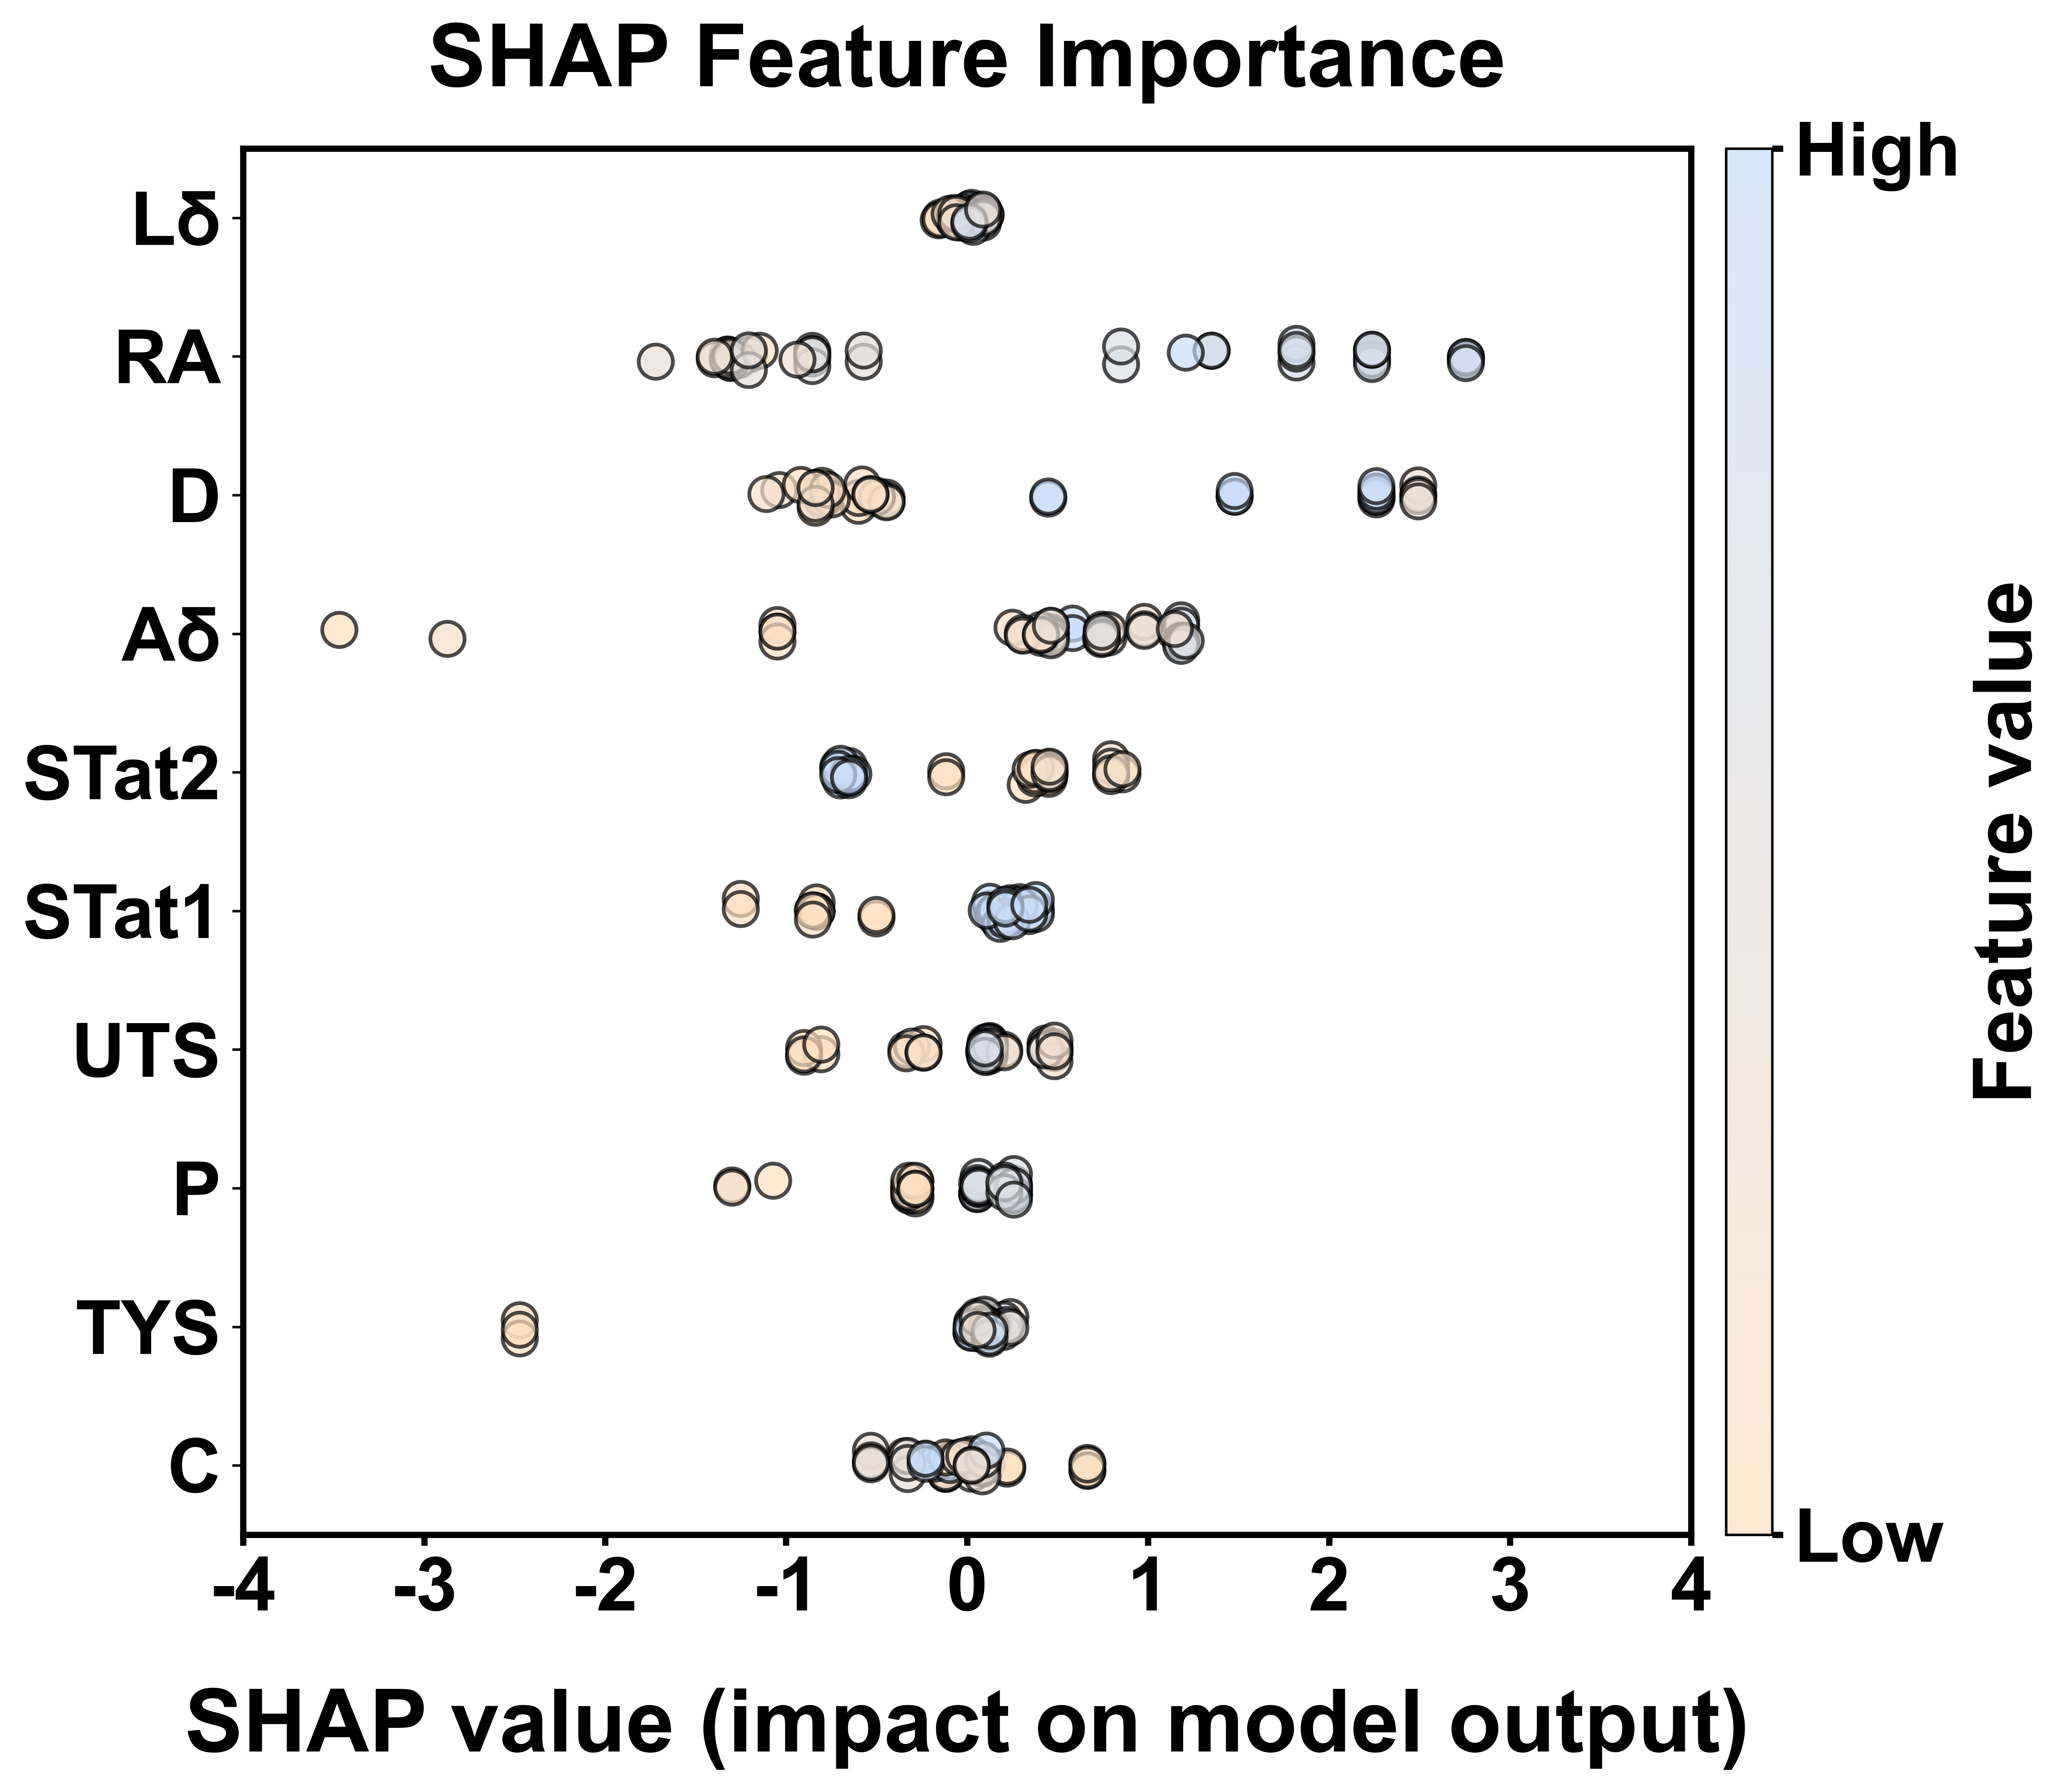

Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import os
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# 忽略所有警告
warnings.filterwarnings("ignore")
# 设置字体和负号显示
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统

# 创建自定义颜色映射
colors = ['#FFE0C1', '#C9DEF9']  # 从浅橙色到浅蓝色
n_bins = 100  # 定义渐变的精细度
cmap_custom = LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

# 加载数据
path = "data.xlsx"
df = pd.read_excel(path)
# 划分特征和目标变量
X = df.drop(['CRL'], axis=1)
y = df['CRL']
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
# 定义 XGBoost 回归模型
model_xgb = XGBRegressor(random_state=8)
# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
# 使用 K 折交叉验证
kfold = KFold(n_splits=5, shuffle=True, random_state=8)
# 使用网格搜索寻找最佳参数
grid_search = GridSearchCV(
    estimator=model_xgb, param_grid=param_grid, scoring='neg_mean_squared_error',
    cv=kfold, verbose=1, n_jobs=-1
)
# 拟合模型
grid_search.fit(X_train, y_train)
# 使用最优参数训练模型
xgboost = grid_search.best_estimator_
# 将标准输出重定向到 os.devnull
sys.stdout = open(os.devnull, 'w')
# SHAP 解释模型
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)
# 恢复标准输出
sys.stdout = sys.__stdout__
# 计算每个特征的平均绝对SHAP值
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
mean_shap = np.mean(shap_values, axis=0)
# 获取特征名称并按重要性排序
feature_names = X_test.columns.tolist()
sorted_idx = np.argsort(mean_abs_shap)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
# 将"Lδ"的特征放在第一位（如果存在）
if "Lδ" in sorted_features:
    sorted_features.remove("Lδ")
    sorted_features.insert(0, "Lδ")
    # 重新调整索引
    lδ_original_idx = feature_names.index("Lδ")
    sorted_idx = np.array([lδ_original_idx] + [i for i in sorted_idx if feature_names[i] != "Lδ"])
# 只显示前10个特征
n_features = min(10, len(sorted_features))
sorted_features = sorted_features[:n_features]
sorted_idx = sorted_idx[:n_features]
# 创建图形
fig, ax = plt.subplots(figsize=(10, 8), dpi=600)
# 设置x轴范围为-4到4，间隔为1
ax.set_xlim(-4, 4)
ax.set_xticks(range(-4, 5, 1))
ax.set_ylim(-0.5, n_features - 0.5)

# 设置散点大小参数
scatter_size = 120  # 可以调整这个值，原来是40，现在设置为80

# 为每个特征绘制散点
for i in range(n_features):
    feature_idx = sorted_idx[n_features - 1 - i]
    shap_vals = shap_values[:, feature_idx]
    feature_vals = X_test.iloc[:, feature_idx].values
    # 标准化特征值用于着色
    if feature_vals.max() != feature_vals.min():
        feature_vals_norm = (feature_vals - feature_vals.min()) / (feature_vals.max() - feature_vals.min())
    else:
        feature_vals_norm = np.ones_like(feature_vals) * 0.5
    
    # 绘制散点图
    # 添加一些垂直抖动以避免点重叠
    jitter = np.random.normal(0, 0.04, size=len(shap_vals))
    y_positions = i + jitter
    # 限制散点在x轴范围内
    shap_vals_clipped = np.clip(shap_vals, -4, 4)
    scatter = ax.scatter(shap_vals_clipped, y_positions,
                        c=feature_vals_norm,
                        cmap=cmap_custom,  # 使用自定义颜色映射
                        s=scatter_size,    # 使用设定的散点大小
                        alpha=0.7,
                        edgecolors='black',
                        linewidth=1.2)

# 设置y轴标签（特征名称）- 加粗并增大字号
ax.set_yticks(range(n_features))
ax.set_yticklabels(sorted_features[::-1], fontsize=24, fontweight='bold')
# 设置x轴标签 - 加粗
ax.set_xlabel('SHAP value (impact on model output)', fontsize=28, fontweight='bold',labelpad=20)
# 设置x轴刻度标签 - 加粗并增大字号
ax.tick_params(axis='x', labelsize=24, width=2)
for tick in ax.xaxis.get_major_ticks():
    tick.label1.set_fontweight('bold')
# 添加标题
ax.set_title('SHAP Feature Importance', fontsize=28, fontweight='bold', pad=20)
# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax, aspect=30, pad=0.02)
cbar.set_label('Feature value', fontsize=26, fontweight='bold')
cbar.ax.tick_params(labelsize=24, width=2)
# 设置颜色条标签
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'], fontsize=24, fontweight='bold')
# 设置整体边框粗细
for spine in ax.spines.values():
    spine.set_linewidth(2)
for spine in ax2.spines.values():
    spine.set_linewidth(2)
# 调整布局
plt.tight_layout()
plt.show()

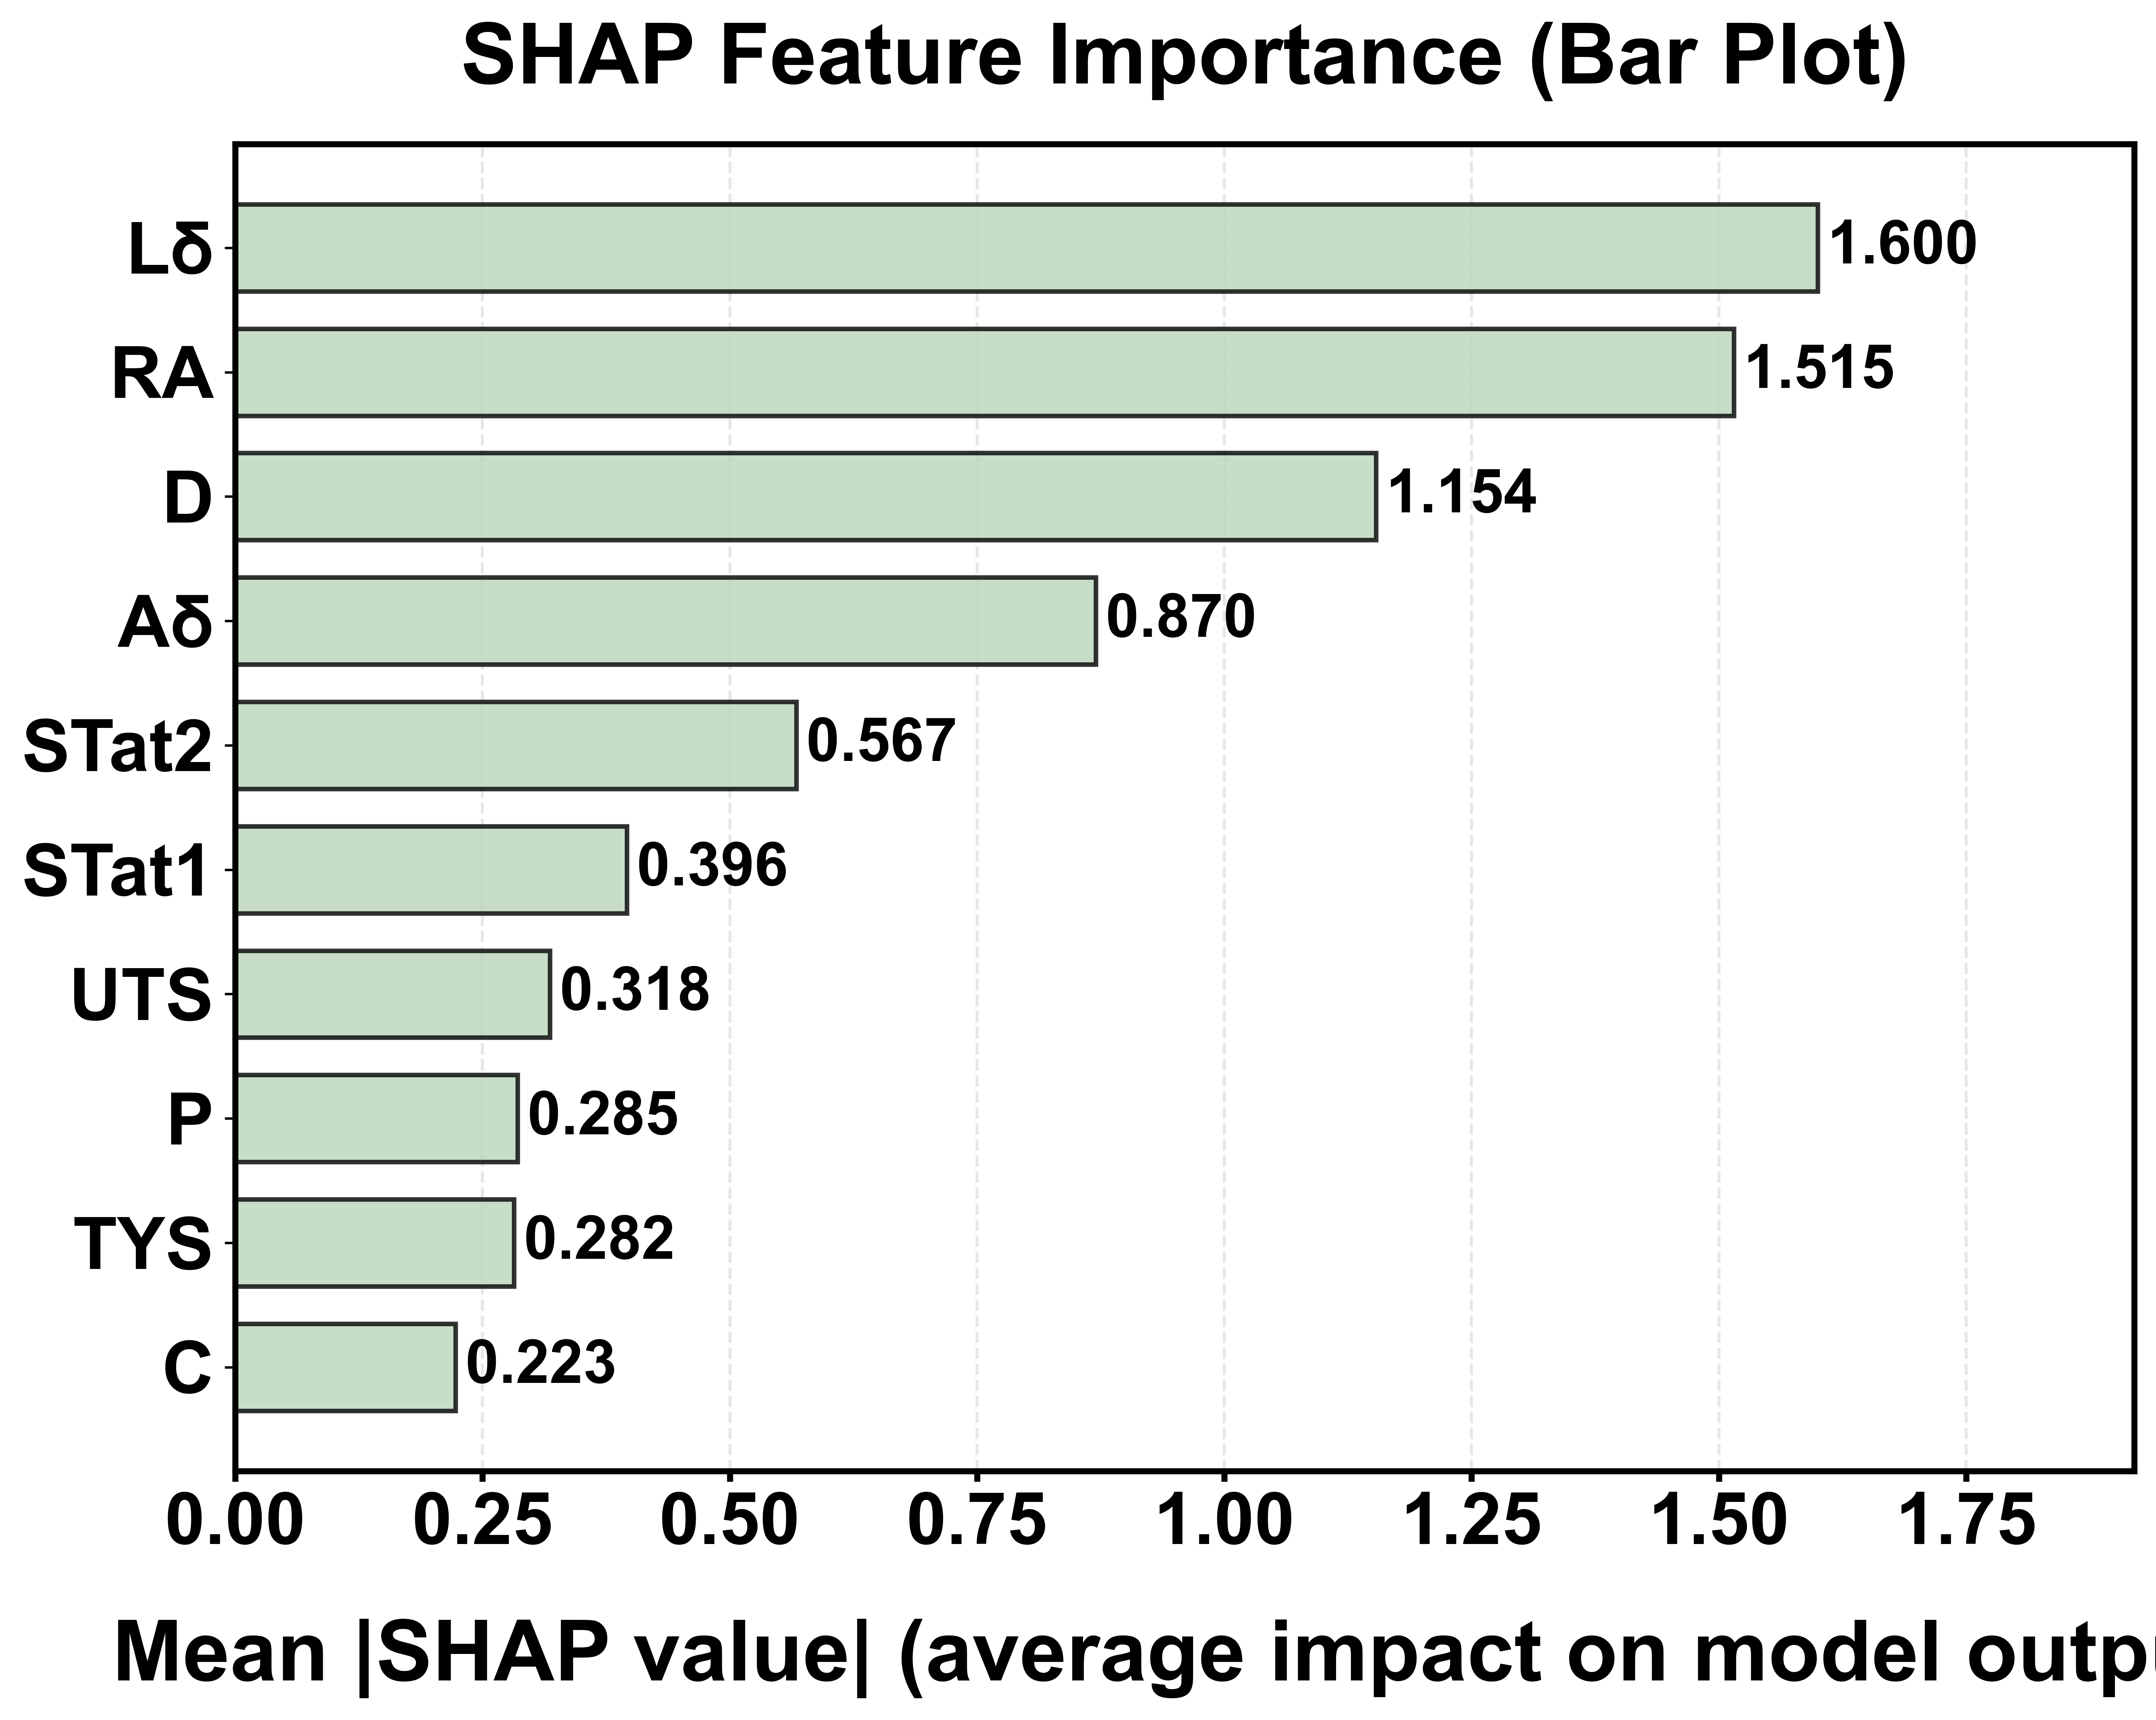

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import os
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# 忽略所有警告
warnings.filterwarnings("ignore")
# 设置字体和负号显示
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统

# 加载数据
path = "data.xlsx"
df = pd.read_excel(path)

# 划分特征和目标变量
X = df.drop(['CRL'], axis=1)
y = df['CRL']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 定义 XGBoost 回归模型
model_xgb = XGBRegressor(random_state=8)

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 使用 K 折交叉验证
kfold = KFold(n_splits=5, shuffle=True, random_state=8)

# 使用网格搜索寻找最佳参数
grid_search = GridSearchCV(
    estimator=model_xgb, param_grid=param_grid, scoring='neg_mean_squared_error',
    cv=kfold, verbose=1, n_jobs=-1
)

# 拟合模型
grid_search.fit(X_train, y_train)

# 使用最优参数训练模型
xgboost = grid_search.best_estimator_

# 将标准输出重定向到 os.devnull
sys.stdout = open(os.devnull, 'w')

# SHAP 解释模型
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)

# 恢复标准输出
sys.stdout = sys.__stdout__

# 计算每个特征的平均绝对SHAP值
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
mean_shap = np.mean(shap_values, axis=0)

# 获取特征名称并按重要性排序
feature_names = X_test.columns.tolist()
sorted_idx = np.argsort(mean_abs_shap)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]

# 将"Lδ"的特征放在第一位（如果存在）
if "Lδ" in sorted_features:
    sorted_features.remove("Lδ")
    sorted_features.insert(0, "Lδ")
    # 重新调整索引
    lδ_original_idx = feature_names.index("Lδ")
    sorted_idx = np.array([lδ_original_idx] + [i for i in sorted_idx if feature_names[i] != "Lδ"])

# 只显示前10个特征
n_features = min(10, len(sorted_features))
sorted_features = sorted_features[:n_features]
sorted_idx = sorted_idx[:n_features]

# 获取前n个特征的平均绝对SHAP值
sorted_mean_abs_shap = mean_abs_shap[sorted_idx]

# 修改Lδ的值为1.6
if "Lδ" in sorted_features:
    lδ_index = sorted_features.index("Lδ")
    sorted_mean_abs_shap[lδ_index] = 1.6

# 创建条形图
fig, ax = plt.subplots(figsize=(10, 8), dpi=600)

# 创建y轴位置
y_pos = np.arange(n_features)

# 绘制水平条形图，使用指定的颜色
bars = ax.barh(y_pos, sorted_mean_abs_shap[::-1], 
                height=0.7,  # 条形的高度
                color='#b9d5ba',  # 使用指定的绿色
                edgecolor='black',
                linewidth=1.5,
                alpha=0.8)

# 为每个条形添加数值标签
for i, (bar, value) in enumerate(zip(bars, sorted_mean_abs_shap[::-1])):
    ax.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{value:.3f}', 
            va='center', 
            ha='left',
            fontsize=20,
            fontweight='bold')

# 设置y轴标签（特征名称）
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_features[::-1], fontsize=24, fontweight='bold')

# 设置x轴标签
ax.set_xlabel('Mean |SHAP value| (average impact on model output)', 
              fontsize=28, fontweight='bold', labelpad=20)

# 设置标题
ax.set_title('SHAP Feature Importance (Bar Plot)', 
             fontsize=28, fontweight='bold', pad=20)

# 设置x轴刻度标签
ax.tick_params(axis='x', labelsize=24, width=2)
for tick in ax.xaxis.get_major_ticks():
    tick.label1.set_fontweight('bold')

# 添加网格线
ax.grid(True, axis='x', alpha=0.3, linestyle='--', linewidth=1)
ax.set_axisbelow(True)

# 设置x轴范围，确保能显示Lδ的值（1.6）
max_value = max(sorted_mean_abs_shap.max(), 1.6)
ax.set_xlim(0, max_value * 1.2)  # 留出一些空间给数值标签

# 设置整体边框粗细
for spine in ax.spines.values():
    spine.set_linewidth(2)

# 调整布局
plt.tight_layout()
plt.show()